# DATA301/DATA471 — Assignment IV

Exercise 1 is comparing estimators for the exponential rate parameter. Exercise 2 is a visual analysis of the `ausbeer` time series.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(2024)
plt.rcParams['figure.figsize'] = (9, 4.5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

## Exercise 1

### Part 1 — quantile types (10%)

I read through Wicklin's post on the 9 sample quantile definitions from Hyndman & Fan (1996). Quick summary:

- 3 of the types just round to an actual data point, the other 6 interpolate between two points instead.
- They all come from the same general formula really — pick two nearby sorted values and blend between them, just differently depending on the type.
- Rounding types (1–3) always give a real observed value, or the average of two. Interpolation types (4–9) can land anywhere in between, so the quantile function ends up smoother.
- SAS defaults to type 2. R defaults to type 7.
- The types mostly only disagree when the sample is small or there are big gaps between values. Past ~100 points they're basically the same, apart from maybe the extreme tails.
- Wicklin's main point was that the choice barely matters for bigger samples, but it's still worth stating which one you used, especially for small n.

For this assignment I went with type 7, since it's an interpolation method and gives a smooth quantile function, which fits a continuous distribution like the exponential. It's also what both R and numpy default to, so `np.quantile(x, [0.25, 0.75])` already gives the right thing without setting anything extra.

- R: `quantile()` → type 7 by default
- Python: `numpy.quantile()` → `method='linear'`, same as type 7
- pandas' `.quantile()` uses the same default

In [2]:
# quick check: the 9 types vs the numpy/R default
x_demo = np.array([0, 1, 1, 1, 2, 2, 2, 4, 5, 8], dtype=float)
hf_types = ['inverted_cdf', 'averaged_inverted_cdf', 'closest_observation',
            'interpolated_inverted_cdf', 'hazen', 'weibull', 'linear',
            'median_unbiased', 'normal_unbiased']

for i, t in enumerate(hf_types, start=1):
    q1, q3 = np.percentile(x_demo, [25, 75], method=t)
    tag = '  <- default (type 7)' if t == 'linear' else ''
    print(f'type {i} ({t}): Q1={q1:.3f}  Q3={q3:.3f}{tag}')

type 1 (inverted_cdf): Q1=1.000  Q3=4.000
type 2 (averaged_inverted_cdf): Q1=1.000  Q3=4.000
type 3 (closest_observation): Q1=1.000  Q3=4.000
type 4 (interpolated_inverted_cdf): Q1=1.000  Q3=3.000
type 5 (hazen): Q1=1.000  Q3=4.000
type 6 (weibull): Q1=1.000  Q3=4.250
type 7 (linear): Q1=1.000  Q3=3.500  <- default (type 7)
type 8 (median_unbiased): Q1=1.000  Q3=4.083
type 9 (normal_unbiased): Q1=1.000  Q3=4.062


### Part 2 — bootstrap bias correction (20%)

Estimators:

$$\hat\lambda_{ML}(X) = \left(\frac{1}{n}\sum_{i=1}^n X_i\right)^{-1}, \qquad
\hat\lambda_{IQR}(X) = \frac{\ln 3}{q_{3/4}(X) - q_{1/4}(X)}$$

The idea behind bootstrap bias correction: bias is just (average of the estimator) minus (true value), but we obviously don't know the true value. So instead we pretend the sample is the population, and pretend our estimate is the truth. Then:

- resample the data with replacement, $B$ times, each resample the same size $n$
- run the IQR estimator on every resample
- average those $B$ estimates and subtract off the original estimate — that's the bias estimate
- subtract that bias estimate from the original to get the corrected version, $\tilde\lambda$

$$\tilde\lambda(X) = 2\,\hat\lambda_{IQR}(X) - \frac{1}{B}\sum_{b=1}^B \hat\lambda_{IQR}(X^{*b})$$

Used $B=200$ like the assignment asks.

One thing I ran into: with $n=5$, a lot of the bootstrap resamples end up with repeated values (you're only drawing from 5 numbers), and sometimes that makes $q_{3/4}$ and $q_{1/4}$ come out equal, which breaks the IQR estimator — divide by zero. I just filter out the non-finite bootstrap estimates before averaging, which seems like the standard fix.

In [3]:
def lambda_ml(x, axis=-1):
    return 1 / np.mean(x, axis=axis)

def lambda_iqr(x, axis=-1):
    q1, q3 = np.quantile(x, [0.25, 0.75], axis=axis)
    with np.errstate(divide='ignore', invalid='ignore'):
        return np.log(3) / (q3 - q1)

def lambda_iqr_bc(x, B=200, rng=rng):
    n = len(x)
    theta = lambda_iqr(x)
    boot = lambda_iqr(x[rng.integers(0, n, (B, n))], axis=1)
    boot = boot[np.isfinite(boot)]
    bias = boot.mean() - theta if len(boot) else 0
    return theta - bias

### Part 3 — Monte Carlo comparison (20%)

For each combination of $\lambda$ and $n$ I generate $M$ samples, run all three estimators on each one, and average the squared error to get the MSE.

I used $M=2000$ everywhere. I also computed the standard error of each MSE estimate, and for the ML and IQR estimators that stayed under roughly 10% of the MSE itself, which felt precise enough to actually compare the three. 2000 reps also runs the whole grid in a few seconds, so there wasn't much reason to use less.

The one weird case is the bootstrap-corrected estimator at $n=5$. Its MSE comes out huge and kind of unstable — I tried bumping $M$ up to 10,000 just to check, and the MSE actually got bigger and noisier, not more precise. So it's not a "need more reps" problem, the estimator itself just has a really heavy tail at that sample size. I still report the number, but I wouldn't trust it much.

In [4]:
def mc_mse(lam, n, M=2000, B=200):
    X = rng.exponential(1 / lam, size=(M, n))
    ml  = lambda_ml(X, axis=1)
    iqr = lambda_iqr(X, axis=1)
    bc  = np.array([lambda_iqr_bc(x, B) for x in X])

    def mse_se(est):
        sq = (est - lam) ** 2
        return sq.mean(), sq.std(ddof=1) / np.sqrt(M)

    return mse_se(ml), mse_se(iqr), mse_se(bc)

rows = []
for lam in [0.1, 1, 10]:
    for n in [5, 30, 100]:
        (mse_ml, se_ml), (mse_iqr, se_iqr), (mse_bc, se_bc) = mc_mse(lam, n)
        rows.append([lam, n, mse_ml, se_ml, mse_iqr, se_iqr, mse_bc, se_bc])

results = pd.DataFrame(rows, columns=['lambda', 'n', 'MSE_ML', 'SE_ML',
                                       'MSE_IQR', 'SE_IQR', 'MSE_BC', 'SE_BC'])
pd.set_option('display.float_format', lambda v: f'{v:,.5g}')
results

,lambda,n,MSE_ML,SE_ML,MSE_IQR,SE_IQR,MSE_BC,SE_BC
0,0.1,5,0.0069069,0.00087277,0.1969,0.03654,"1,738","1,708.5"
1,0.1,30,0.00038802,1.7516e-05,0.0012684,6.4398e-05,0.0013722,7.2729e-05
2,0.1,100,0.00010417,3.5275e-06,0.00024897,9.377e-06,0.00028786,1.0787e-05
3,1,5,0.59909,0.062738,15.884,2.8205,2.4587e+06,2.4426e+06
4,1,30,0.041277,0.0018481,0.13598,0.0087025,0.14374,0.0097878
5,1,100,0.01128,0.00040899,0.0257,0.00099239,0.02972,0.0010868
6,10,5,56.273,4.2284,"2,655.9",513.74,3.447e+05,1.4645e+05
7,10,30,4.1626,0.1761,11.803,0.59328,12.794,0.64467
8,10,100,1.0601,0.037524,2.4945,0.10426,2.8307,0.11638


Some things that stood out from the table:

- ML wins every single time, which makes sense since it's the maximum likelihood estimator and uses the whole sample, not just two order statistics.
- IQR is noticeably worse than ML across the board, and that gap doesn't really close as $n$ gets bigger.
- The bootstrap correction doesn't actually help at $n=30$ or $n=100$ — if anything its MSE is a touch higher than plain IQR. My guess is correcting for bias adds variance from all the resampling, and here that extra variance costs more than the bias correction saves.
- At $n=5$ everything gets worse, but the corrected estimator specifically falls apart (see the note in Part 3). So bootstrap-correcting an IQR estimator with only 5 points is a bad idea, it makes things worse, not better.
- MSE roughly scales with $\lambda^2$ across all three, which tracks since these are all scale estimators.

## Exercise 2 — `ausbeer` (50%)

Using the actual `ausbeer` data from the `fpp2` R package (Australian Bureau of Statistics) — quarterly beer production in Australia, in megalitres, from 1956 Q1 to 2010 Q2 (218 points). Pulled it from a CSV mirror of the same data so it matches what `data(ausbeer)` gives in R.

In [5]:
beer = pd.read_csv('ausbeer.csv')
year = beer['time'].astype(int)
beer['year'] = year
beer['quarter'] = np.round((beer['time'] - year) * 4).astype(int) + 1
beer['value'] = beer['value'].astype(float)
beer['date'] = pd.to_datetime(dict(year=beer['year'], month=(beer['quarter']-1)*3+1, day=1))
beer = beer[['date', 'year', 'quarter', 'value']]
beer.head()

,date,year,quarter,value
0,1956-01-01,1956,1,284
1,1956-04-01,1956,2,213
2,1956-07-01,1956,3,227
3,1956-10-01,1956,4,308
4,1957-01-01,1957,1,262


**1. Frequency**

It's quarterly, 4 points a year. You can tell from the metadata, but also just from the data itself — the `time` column jumps in steps of 0.25, and if you look at the plot below, the same up-down-down-up wiggle repeats 4 times every year.

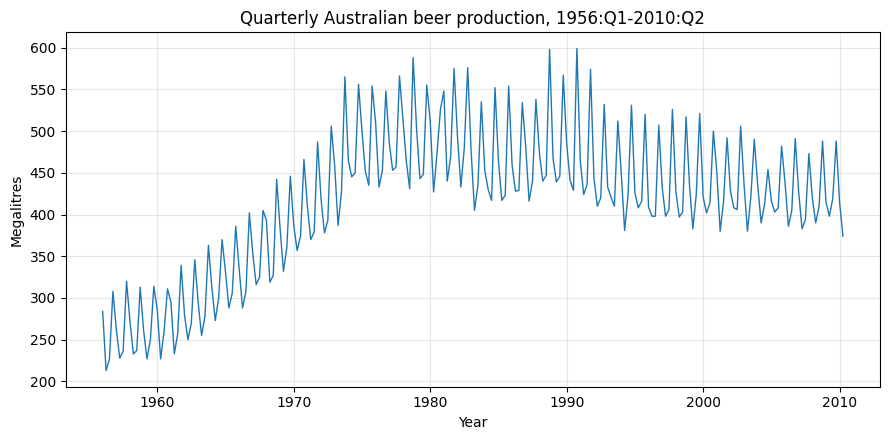

In [6]:
fig, ax = plt.subplots()
ax.plot(beer['date'], beer['value'], lw=1)
ax.set_title('Quarterly Australian beer production, 1956:Q1-2010:Q2')
ax.set_xlabel('Year'); ax.set_ylabel('Megalitres')
plt.tight_layout(); plt.show()

**2. Trend**

There's definitely a trend but it's not a straight line — production climbs from around 260 ML/quarter in the late 50s up to a peak near 480 around 1980, then slowly drops off through the 90s and 2000s, ending up back around 390–420 by 2010. So it's more of a hump shape than a consistent up or down trend.

In [7]:
beer.assign(decade=(beer['year']//10)*10).groupby('decade')['value'].mean()

decade
1950   261.56
1960   321.12
1970   461.82
1980    477.9
1990   449.23
2000   429.38
2010      394
Name: value, dtype: float64

**3. Seasonality**

Yeah, there's a clear yearly pattern — Q4 is always the highest quarter, Q2 is always the lowest, Q1 and Q3 sit in the middle. Probably ties into Australian summer and Christmas landing in Q4. And it's not just an average thing, this pattern shows up in basically every single year.

In [8]:
seasonal_means = beer.groupby('quarter')['value'].agg(['mean', 'std'])
seasonal_means

,mean,std
quarter,,
1,416.82,73.16
2,372.62,71.294
3,387.37,69.341
4,485.44,84.004


**4. Variability**

Not perfectly constant. The seasonal swing (max minus min quarter) grows from about 89 ML in the 50s up to 128 in the 70s/80s, roughly tracking the rise in production, then shrinks back down as production falls after 1990. If you look at the relative swing instead (divide by the level), it's a lot steadier, sitting somewhere between 0.2 and 0.35 the whole time. So there's a mild multiplicative thing going on, but it's not dramatic — a log transform would help a bit, but the variance isn't exploding or anything.

In [9]:
dec = beer.assign(decade=(beer['year']//10)*10).groupby(['decade','quarter'])['value'].mean().unstack()
dec['level'] = dec[[1,2,3,4]].mean(axis=1)
dec['range'] = dec[[1,2,3,4]].max(axis=1) - dec[[1,2,3,4]].min(axis=1)
dec['range_over_level'] = dec['range'] / dec['level']
dec[['level', 'range', 'range_over_level']]

quarter,level,range,range_over_level
decade,,,
1950,261.56,88.5,0.33835
1960,321.12,102.9,0.32044
1970,461.83,120.9,0.26179
1980,477.9,128,0.26784
1990,449.23,127.8,0.28449
2000,429.38,94.4,0.21985
2010,394,40,0.10152


**5. Unusual points**

Ran a quick additive decomposition and looked at the residuals. The standout points are three big Q4s in a row — 1988, 1990, 1991 — with 1990 Q4 the highest value in the entire series (599 ML), sitting about 49 ML above what you'd expect from trend + season. There's also a spike in early 1981. A couple of quarters (1978 Q3, 1980 Q4) come in unusually low too, but the high outliers are more extreme.

In [10]:
from statsmodels.tsa.seasonal import seasonal_decompose

s = pd.Series(beer['value'].values, index=beer['date'])
resid = seasonal_decompose(s, model='additive', period=4).resid.dropna()
top = resid.abs().sort_values(ascending=False).head(6)
pd.DataFrame({'date': top.index.date, 'value': s[top.index].values, 'residual': resid[top.index].values})

,date,value,residual
0,1981-01-01,548,49.619
1,1990-10-01,599,48.98
2,1988-10-01,598,41.23
3,1978-07-01,431,-38.494
4,1980-10-01,526,-38.02
5,1991-10-01,574,37.605


**6. Seasonal plot**

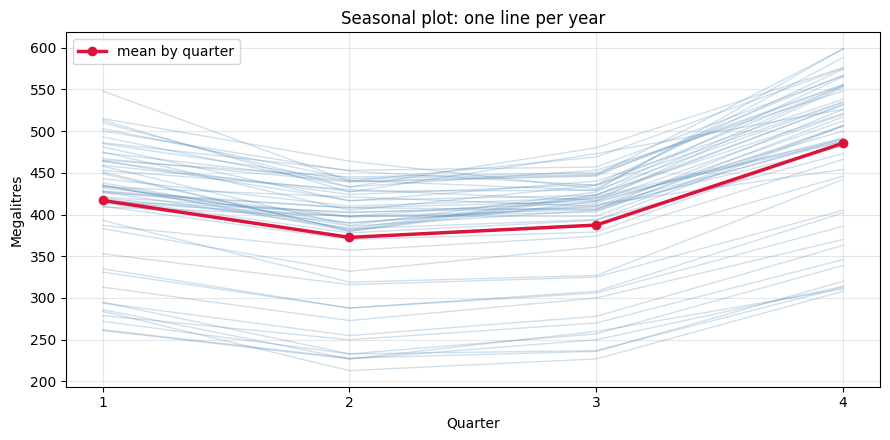

In [11]:
fig, ax = plt.subplots()
for yr, grp in beer.groupby('year'):
    grp = grp.sort_values('quarter')
    ax.plot(grp['quarter'], grp['value'], color='steelblue', alpha=0.25, lw=1)
ax.plot(seasonal_means.index, seasonal_means['mean'], color='crimson', lw=2.5, marker='o', label='mean by quarter')
ax.set_xticks([1,2,3,4]); ax.set_xlabel('Quarter'); ax.set_ylabel('Megalitres')
ax.set_title('Seasonal plot: one line per year'); ax.legend()
plt.tight_layout(); plt.show()

Plotting every year's quarters on the same x-axis makes the seasonal shape a lot easier to see than the raw time series. Most years trace the same rise-dip-recover-spike shape, and you can watch the whole bundle of lines drift up through the 60s–80s and back down after. The Q4 outliers from the last question also stand out more clearly here, sitting above the rest of the pack right at Q4.

**7. Seasonal subseries plot**

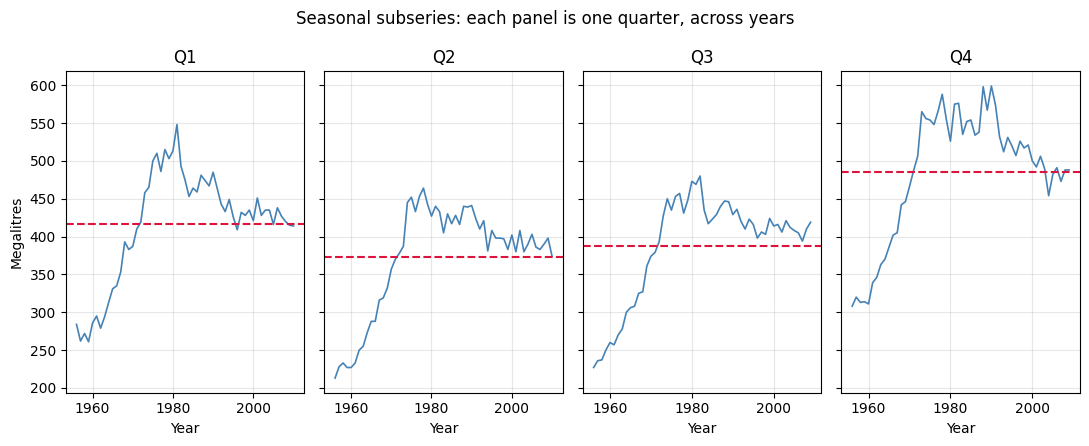

In [12]:
fig, axes = plt.subplots(1, 4, figsize=(11, 4.5), sharey=True)
for q, ax in zip([1,2,3,4], axes):
    sub = beer[beer['quarter'] == q].sort_values('year')
    ax.plot(sub['year'], sub['value'], color='steelblue', lw=1.2)
    ax.axhline(sub['value'].mean(), color='crimson', ls='--', lw=1.5)
    ax.set_title(f'Q{q}'); ax.set_xlabel('Year')
axes[0].set_ylabel('Megalitres')
fig.suptitle('Seasonal subseries: each panel is one quarter, across years')
plt.tight_layout(); plt.show()

Same story — Q4 highest, Q2 lowest, and that ranking barely budges across 55 years. What's interesting is each panel still shows the same hump-shaped trend as the whole series, just shifted up or down depending on the quarter. So trend and seasonality seem to be acting pretty independently of each other.

**8. Detrend or transform?**

Detrending — yeah, for sure. The trend actually changes direction partway through, so a model assuming a flat or linear trend is going to fit badly no matter what. You'd want seasonal differencing or some kind of non-linear trend term.

Transform — only maybe. There's some evidence the seasonal swing grows with the level (see section 4), which usually points towards a log transform, but the relative swing doesn't blow out that much over 55 years, so it's not a strong case either way. I'd probably try log anyway just to see if it tidies up the residuals, but I wouldn't say it's essential.

No model is fit here, just the visual argument, per the instructions.